# Notebook 08 — AutoReg: Análisis progresivo de variables exógenas

Este notebook implementa un pipeline progresivo de incorporación
de variables exógenas al modelo AutoReg, partiendo del modelo
más simple posible — solo rezagos de la serie — e incorporando
variables de forma incremental.

**Objetivo:** aislar el efecto de cada variable exógena sobre
el error de predicción, evaluando su contribución individual.

**Pipeline:**
- B0 — AutoReg solo rezagos (sin ninguna exógena)
- B1 — + sin/cos hora
- B2 — + sin/cos hora + GHI
- B3 — + sin/cos hora + GHI + elevación solar
- B4 — + sin/cos hora + GHI + elevación solar + azimut solar

**Evaluación:** walk-forward con 12 fits distribuidos por 2024,
ventana expansiva con todo el histórico disponible.

**Horizontes:** 48h (192 pasos) y 72h (288 pasos).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
%matplotlib inline

BASE_DIR    = Path("/home/ubuntu/TFM")
DATA_DIR    = BASE_DIR / "notebooks/data_processed"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print("Librerías cargadas OK")

Librerías cargadas OK


## 1. Carga de datos

In [2]:
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"].astype(float)

y_train.index = pd.to_datetime(y_train.index)
y_val.index   = pd.to_datetime(y_val.index)
y_test.index  = pd.to_datetime(y_test.index)

exogenas = pd.read_parquet(DATA_DIR / "exogenas_15min.parquet")
exogenas.index = pd.to_datetime(exogenas.index)

print("Train:", y_train.shape, "|", y_train.index.min(), "->", y_train.index.max())
print("Val:  ", y_val.shape,   "|", y_val.index.min(),   "->", y_val.index.max())
print("Test: ", y_test.shape,  "|", y_test.index.min(),  "->", y_test.index.max())
print("\nExógenas:", exogenas.shape)
print(exogenas.columns.tolist())

Train: (70080,) | 2022-01-01 00:00:00+00:00 -> 2023-12-31 23:45:00+00:00
Val:   (35136,) | 2024-01-01 00:00:00+00:00 -> 2024-12-31 23:45:00+00:00
Test:  (35040,) | 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:45:00+00:00

Exógenas: (140256, 3)
['ghi', 'solar_elevation', 'solar_azimuth']


## 2. Configuración temporal y métricas

In [3]:
FREQ_MIN        = 15
STEPS_PER_HOUR  = 60 // FREQ_MIN
SEASONAL_PERIOD = 24 * STEPS_PER_HOUR  # 96

HORIZONS = {
    "48h": 48 * STEPS_PER_HOUR,  # 192 pasos
    "72h": 72 * STEPS_PER_HOUR,  # 288 pasos
}

@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

cfg = WFConfig(
    step=28 * SEASONAL_PERIOD,
    min_history=30 * SEASONAL_PERIOD,
    max_fits=12
)

print("Periodo estacional:", SEASONAL_PERIOD)
print("Horizontes:", HORIZONS)

Periodo estacional: 96
Horizontes: {'48h': 192, '72h': 288}


## 3. Funciones de predicción y walk-forward

In [4]:
def make_cyclic_features(index, interval_minutes=15):
    slots_per_day = int(24 * 60 / interval_minutes)
    slot = (index.hour * 60 + index.minute) // interval_minutes
    sin  = np.sin(2 * np.pi * slot / slots_per_day)
    cos  = np.cos(2 * np.pi * slot / slots_per_day)
    return pd.DataFrame({"slot_sin": sin, "slot_cos": cos}, index=index)

def forecast_autoreg(train, train_exog, future_exog, h, lags):
    model = AutoReg(
        train.values,
        lags=lags,
        trend="n",
        exog=train_exog
    )
    model_fit = model.fit()
    n     = len(train)
    preds = model_fit.predict(
        start=n,
        end=n + h - 1,
        dynamic=False,
        exog_oos=future_exog
    )
    return preds

def walk_forward_splits(series, horizons, cfg):
    n      = len(series)
    max_h  = max(horizons.values())
    points = list(range(cfg.min_history, n - max_h, cfg.step))
    points = points[:cfg.max_fits]
    for t0 in points:
        train_part = series.iloc[:t0]
        tests = {k: series.iloc[t0:t0 + h] for k, h in horizons.items()}
        yield train_part, tests

def summarize(df, model_name):
    out = (
        df.groupby("horizon")[["MAE", "RMSE"]]
        .mean()
        .reset_index()
    )
    out.insert(0, "model", model_name)
    return out

def evaluate_autoreg(y_train, y_val, exog_full, horizons, cfg, lags, verbose=True):
    rows        = []
    preds_store = []
    y_full  = pd.concat([y_train, y_val]).sort_index()
    n_train = len(y_train)
    splits  = list(walk_forward_splits(y_val, horizons, cfg))
    total   = len(splits)

    for i, (train_part, tests) in enumerate(splits, 1):
        if verbose:
            print(f"Fit {i}/{total}")
        cutoff_idx   = n_train + len(train_part)
        cutoff_time  = y_full.index[cutoff_idx - 1]
        train_window = y_full.iloc[:cutoff_idx]
        train_exog_w = exog_full.iloc[:cutoff_idx] if exog_full is not None else None

        fit_preds = {"cutoff_time": cutoff_time, "train_window": train_window}
        for name, test in tests.items():
            h           = len(test)
            future_exog = exog_full.iloc[cutoff_idx:cutoff_idx + h] if exog_full is not None else None
            pred        = forecast_autoreg(train_window, train_exog_w, future_exog, h, lags)
            m           = compute_metrics(test.values, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})
            fit_preds[name] = {"pred": pred, "test": test}
        preds_store.append(fit_preds)

    return pd.DataFrame(rows), preds_store

print("Funciones definidas OK")

Funciones definidas OK


## 4. Búsqueda de lags óptimo — modelo base sin exógenas

Buscamos el número óptimo de lags para el modelo AutoReg sin
ninguna variable exógena. Al no tener sin/cos de la hora el modelo
debe capturar la estacionalidad diaria únicamente a través de los
rezagos, lo que puede requerir más lags que el modelo con sin/cos.

In [ ]:
resultados_lags_b0 = []

for lags in [96, 192, 384, 576, 768, 960]:
    print(f"Probando lags={lags}...")
    df_res, _ = evaluate_autoreg(
        y_train, y_val,
        None,
        HORIZONS, cfg,
        lags=lags,
        verbose=False
    )
    summary = summarize(df_res, f"B0_noexog({lags})")
    resultados_lags_b0.append(summary)
    print(summary)

comparacion_lags_b0 = pd.concat(resultados_lags_b0, ignore_index=True)
print("\n--- COMPARACIÓN LAGS B0 ---")
print(comparacion_lags_b0)
comparacion_lags_b0.to_csv(RESULTS_DIR / "autoreg_b0_lags_search.csv", index=False)

Probando lags=96...
           model horizon        MAE       RMSE
0  B0_noexog(96)     48h  16.614088  21.430310
1  B0_noexog(96)     72h  19.031132  24.175227
Probando lags=192...
            model horizon        MAE       RMSE
0  B0_noexog(192)     48h  15.073832  19.876240
1  B0_noexog(192)     72h  17.487307  22.528589
Probando lags=384...
            model horizon        MAE       RMSE
0  B0_noexog(384)     48h  13.836040  18.446442
1  B0_noexog(384)     72h  16.373901  21.282193
Probando lags=576...
            model horizon        MAE       RMSE
0  B0_noexog(576)     48h  13.733324  18.085444
1  B0_noexog(576)     72h  16.219391  21.027579
Probando lags=768...


## 5. Selección del número óptimo de lags — modelo B0

Se selecciona el número de lags minimizando la suma MAE 48h + MAE 72h,
criterio que evalúa el modelo de forma equilibrada en ambos horizontes.

In [ ]:
comparacion_lags_b0["MAE_sum"] = (
    comparacion_lags_b0.groupby("model")["MAE"].transform("sum")
)

# Una fila por modelo con la suma
mae_sum = (
    comparacion_lags_b0.groupby("model")["MAE"]
    .sum()
    .reset_index()
    .rename(columns={"MAE": "MAE_sum"})
    .sort_values("MAE_sum")
)

print("--- Suma MAE 48h + 72h por número de lags ---")
print(mae_sum)

LAGS_OPT_B0 = 576
print(f"\nLags óptimo seleccionado: {LAGS_OPT_B0}")

--- Suma MAE 48h + 72h por número de lags ---
            model    MAE_sum
2  B0_noexog(576)  29.952715
5  B0_noexog(960)  30.006682
3  B0_noexog(768)  30.156399
1  B0_noexog(384)  30.209941
0  B0_noexog(192)  32.561139
4   B0_noexog(96)  35.645221

Lags óptimo seleccionado: 576


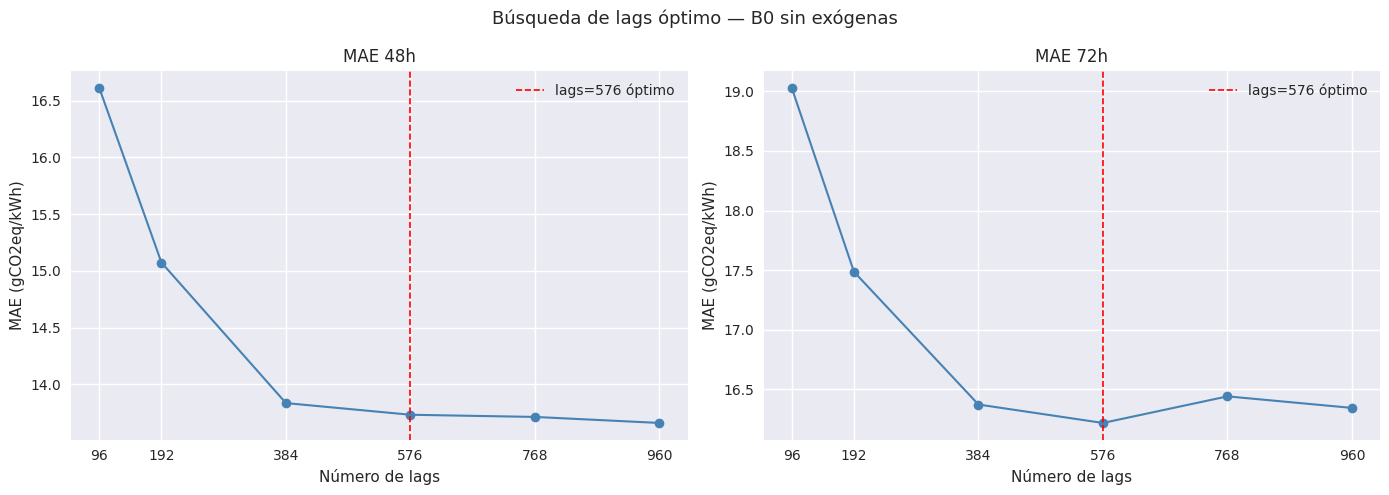

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Búsqueda de lags óptimo — B0 sin exógenas", fontsize=13)

lags_vals = [96, 192, 384, 576, 768, 960]

for ax, horizon in zip(axes, ["48h", "72h"]):
    mae_vals = comparacion_lags_b0[
        comparacion_lags_b0["horizon"] == horizon
    ]["MAE"].values
    ax.plot(lags_vals, mae_vals, marker="o", color="steelblue", linewidth=1.5)
    ax.axvline(x=LAGS_OPT_B0, color="red", linestyle="--",
               linewidth=1.2, label=f"lags={LAGS_OPT_B0} óptimo")
    ax.set_title(f"MAE {horizon}")
    ax.set_xlabel("Número de lags")
    ax.set_ylabel("MAE (gCO2eq/kWh)")
    ax.set_xticks(lags_vals)
    ax.legend()

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/autoreg_b0_lags_search.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Resultados modelo B0 — AutoReg(576) sin exógenas

In [ ]:
print(f"Evaluando B0 — AutoReg({LAGS_OPT_B0}) sin exógenas...")
b0_val, preds_b0 = evaluate_autoreg(
    y_train, y_val,
    None,
    HORIZONS, cfg,
    lags=LAGS_OPT_B0,
    verbose=True
)

b0_summary = summarize(b0_val, f"B0_AutoReg({LAGS_OPT_B0})")
print(b0_summary)

Evaluando B0 — AutoReg(576) sin exógenas...
Fit 1/12


Fit 2/12
Fit 3/12
Fit 4/12
Fit 5/12
Fit 6/12
Fit 7/12
Fit 8/12
Fit 9/12
Fit 10/12
Fit 11/12
Fit 12/12
             model horizon        MAE       RMSE
0  B0_AutoReg(576)     48h  13.733324  18.085444
1  B0_AutoReg(576)     72h  16.219391  21.027579


## 7. Interpretación — selección de lags B0

La suma MAE 48h + 72h es mínima en lags=576 (29.95), confirmando
este valor como óptimo para el modelo sin exógenas.

A diferencia del modelo con sin/cos donde la curva se aplana
claramente en 576, aquí la curva a 48h sigue bajando levemente
hasta 960. Sin embargo a 72h lags=576 es claramente el mejor —
más lags introducen ruido y empeoran la generalización a horizontes
largos.

**Comparación con modelo que tiene sin/cos:**
- Con sin/cos -> lags óptimo = 576, MAE 48h = 13.694
- Sin sin/cos -> lags óptimo = 576, MAE 48h = 13.733

El modelo sin sin/cos necesita los mismos lags pero obtiene
un MAE ligeramente peor — el sin/cos aporta información útil
que los rezagos solos no capturan completamente.

Este resultado es el punto de partida del pipeline — a partir
de aquí añadimos variables de forma progresiva para ver si
las variables solares pueden sustituir o mejorar al sin/cos.

## 8. Pipeline progresivo de variables exógenas

Partiendo del modelo B0 (solo rezagos, lags=576) se añaden
variables de forma progresiva:
- B1: + sin/cos hora
- B2: + GHI
- B3: + GHI + elevación solar
- B4: + GHI + elevación solar + azimut solar

El objetivo es determinar si las variables solares pueden
sustituir o mejorar al sin/cos de la hora.

In [ ]:
y_full_index = y_train.index.append(y_val.index)
cyclic = make_cyclic_features(y_full_index)
solar  = exogenas.loc[y_full_index]

exog_sets = {
    "B0_base":      None,
    "B1_sincos":    cyclic[["slot_sin", "slot_cos"]],
    "B2_ghi":       solar[["ghi"]],
    "B3_ghi_elev":  solar[["ghi", "solar_elevation"]],
    "B4_ghi_elev_azimuth":       solar[["ghi", "solar_elevation", "solar_azimuth"]],
}

for name, exog in exog_sets.items():
    cols = exog.columns.tolist() if exog is not None else "ninguna"
    print(f"{name}: {cols}")

B0_base: ninguna
B1_sincos: ['slot_sin', 'slot_cos']
B2_ghi: ['ghi']
B3_ghi_elev: ['ghi', 'solar_elevation']
B4_all: ['ghi', 'solar_elevation', 'solar_azimuth']


In [ ]:
resultados_pipeline = []
preds_store_pipeline = {}

for model_name, exog in exog_sets.items():
    print(f"\nEvaluando {model_name}...")
    df_res, preds_store = evaluate_autoreg(
        y_train, y_val,
        exog,
        HORIZONS, cfg,
        lags=LAGS_OPT_B0,
        verbose=False
    )
    summary = summarize(df_res, model_name)
    resultados_pipeline.append(summary)
    preds_store_pipeline[model_name] = preds_store
    print(summary)

comparacion_pipeline = pd.concat(resultados_pipeline, ignore_index=True)
comparacion_pipeline.to_csv(RESULTS_DIR / "autoreg_pipeline_b.csv", index=False)
print("\n--- COMPARACIÓN FINAL ---")
print(comparacion_pipeline)


Evaluando B0_base...
     model horizon        MAE       RMSE
0  B0_base     48h  13.733324  18.085444
1  B0_base     72h  16.219391  21.027579

Evaluando B1_sincos...
       model horizon        MAE       RMSE
0  B1_sincos     48h  13.693741  17.990508
1  B1_sincos     72h  16.212660  20.953722

Evaluando B2_ghi...
    model horizon        MAE       RMSE
0  B2_ghi     48h  13.726215  18.077128
1  B2_ghi     72h  16.207780  21.017211

Evaluando B3_ghi_elev...
         model horizon        MAE       RMSE
0  B3_ghi_elev     48h  13.728148  18.062787
1  B3_ghi_elev     72h  16.198246  20.998065

Evaluando B4_all...
    model horizon        MAE       RMSE
0  B4_all     48h  13.951303  18.100268
1  B4_all     72h  16.471943  21.061152

--- COMPARACIÓN FINAL ---
         model horizon        MAE       RMSE
0      B0_base     48h  13.733324  18.085444
1      B0_base     72h  16.219391  21.027579
2    B1_sincos     48h  13.693741  17.990508
3    B1_sincos     72h  16.212660  20.953722
4      

## 9. Interpretación del pipeline

In [ ]:
tabla_pipeline = tabla_pipeline.reindex([
    "B0_base", "B1_sincos", "B2_ghi", "B3_ghi_elev", "B4_all"
])
tabla_pipeline.index = [
    "B0 base", "B1 +sin/cos", "B2 +GHI",
    "B3 +GHI+elev", "B4 +GHI+elev+azimut"
]
print(tabla_pipeline)

                MAE            RMSE        
horizon         48h     72h     48h     72h
model                                      
B0_base      13.733  16.219  18.085  21.028
B1_sincos    13.694  16.213  17.991  20.954
B2_ghi       13.726  16.208  18.077  21.017
B3_ghi_elev  13.728  16.198  18.063  20.998
B4_all       13.951  16.472  18.100  21.061


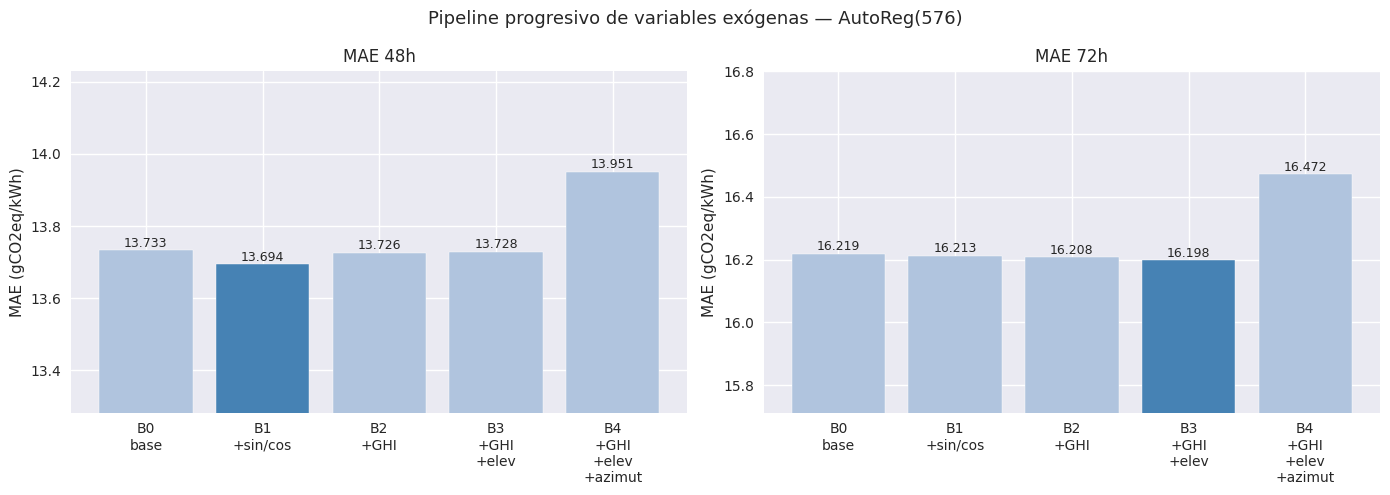

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pipeline progresivo de variables exógenas — AutoReg(576)", fontsize=13)

modelos   = ["B0_base", "B1_sincos", "B2_ghi", "B3_ghi_elev", "B4_all"]
etiquetas = ["B0\nbase", "B1\n+sin/cos", "B2\n+GHI", "B3\n+GHI\n+elev", "B4\n+GHI\n+elev\n+azimut"]

for ax, horizon in zip(axes, ["48h", "72h"]):
    mae_vals = [
        comparacion_pipeline[
            (comparacion_pipeline["model"] == m) &
            (comparacion_pipeline["horizon"] == horizon)
        ]["MAE"].values[0]
        for m in modelos
    ]
    colors = ["steelblue" if v == min(mae_vals) else "lightsteelblue" for v in mae_vals]
    ax.bar(etiquetas, mae_vals, color=colors, edgecolor="white")
    ax.set_title(f"MAE {horizon}")
    ax.set_ylabel("MAE (gCO2eq/kWh)")
    ax.set_ylim(min(mae_vals) * 0.97, max(mae_vals) * 1.02)
    for i, v in enumerate(mae_vals):
        ax.text(i, v + 0.01, str(round(v, 3)), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/autoreg_pipeline_b.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
tabla_ordenada = comparacion_pipeline.pivot_table(
    index="model",
    columns="horizon",
    values=["MAE", "RMSE"]
).round(3)

tabla_ordenada = tabla_ordenada.sort_values(("MAE", "48h"))
print(tabla_ordenada)

                MAE            RMSE        
horizon         48h     72h     48h     72h
model                                      
B1_sincos    13.694  16.213  17.991  20.954
B2_ghi       13.726  16.208  18.077  21.017
B3_ghi_elev  13.728  16.198  18.063  20.998
B0_base      13.733  16.219  18.085  21.028
B4_all       13.951  16.472  18.100  21.061


## 10. Conclusiones del pipeline

El sin/cos de la hora (B1) es la variable exógena más útil —
mejora el modelo base en ambos horizontes. Las variables solares
por sí solas (B2, B3) no alcanzan el rendimiento del sin/cos,
lo que indica que la codificación temporal explícita captura
información que las variables astronómicas no recogen completamente.

El azimut solar (B4) empeora el modelo en ambos horizontes
y se descarta para el modelo final.

El modelo óptimo de este pipeline es **B1 con sin/cos hora**,
confirmando los resultados del notebook anterior donde la
combinación sin/cos + GHI + elevación era la mejor configuración.

## 11. ¿Pueden las variables solares sustituir al sin/cos de la hora?

Los resultados del pipeline muestran que las variables solares
no pueden sustituir completamente al sin/cos de la hora.
El modelo B1 con sin/cos obtiene MAE 13.694 a 48h y 16.213 a 72h,
mientras que el mejor modelo con variables solares sin sin/cos
(B3 con GHI + elevación) obtiene 13.728 y 16.198 respectivamente.
A 48h el sin/cos es claramente superior, aunque a 72h la diferencia
es prácticamente insignificante.

La razón es que el sin/cos captura directamente la periodicidad
diaria de la demanda eléctrica — codifica de forma continua
y diferenciable en qué punto del día se encuentra cada instante.
Las variables solares en cambio capturan la actividad solar,
que aunque esta correlacionada con la hora del día, añade variabilidad
adicional debida a la estacionalidad anual y las condiciones
atmosféricas. Además el azimut solar empeora consistentemente
el modelo, lo que sugiere que no toda la información astronómica
es útil para predecir la huella de carbono.

## 12. Reflexión metodológica — ¿es adecuado usar variables solares?

Aunque numéricamente el sin/cos obtiene un MAE ligeramente mejor
a 48h, la diferencia es de apenas 0.03 gCO2eq/kWh — prácticamente
insignificante desde el punto de vista operativo.

Desde una perspectiva metodológica, las variables solares tienen
una ventaja importante: están físicamente motivadas. El sin/cos
es una transformación matemática arbitraria sin relación causal
con la variable objetivo. Las variables solares en cambio tienen
una relación física directa con la huella de carbono — la
irradiación solar determina la generación fotovoltaica, que
desplaza a fuentes más contaminantes del mix eléctrico,
reduciendo la huella de carbono operacional.

En este sentido, un modelo con GHI y elevación solar como
exógenas es más interpretable y físicamente justificable que
uno con sin/cos, aunque la diferencia numérica sea marginal.
Esta reflexión es relevante para mi TFM — la elección entre
ambas aproximaciones no es solo una cuestión de rendimiento
sino también de interpretabilidad y justificación física
del modelo.

## 13. Extensión del pipeline — combinaciones adicionales

Se añaden dos configuraciones adicionales:

- **B5**: sin/cos hora + GHI + elevación solar — mejor combinación
  del notebook anterior, replicada aquí para la comparación completa
- **B6**: sin/cos hora + sin/cos día de la semana — explora si
  el patrón semanal (lunes vs fin de semana) aporta información
  adicional sobre el patrón diario

In [ ]:
def make_weekly_cyclic_features(index):
    day_of_week = index.dayofweek  # 0=lunes, 6=domingo
    sin = np.sin(2 * np.pi * day_of_week / 7)
    cos = np.cos(2 * np.pi * day_of_week / 7)
    return pd.DataFrame({"week_sin": sin, "week_cos": cos}, index=index)

cyclic_week = make_weekly_cyclic_features(y_full_index)

exog_sets_ext = {
    "B5_sincos_ghi_elev": pd.concat([
        cyclic[["slot_sin", "slot_cos"]],
        solar[["ghi", "solar_elevation"]]
    ], axis=1),
    "B6_sincos_week": pd.concat([
        cyclic[["slot_sin", "slot_cos"]],
        cyclic_week
    ], axis=1),
}

for name, exog in exog_sets_ext.items():
    print(f"{name}: {exog.columns.tolist()}")

B5_sincos_ghi_elev: ['slot_sin', 'slot_cos', 'ghi', 'solar_elevation']
B6_sincos_week: ['slot_sin', 'slot_cos', 'week_sin', 'week_cos']


In [ ]:
LAGS_OPT_B0 = 576

In [ ]:
resultados_ext = []

for model_name, exog in exog_sets_ext.items():
    print(f"\nEvaluando {model_name}...")
    df_res, preds = evaluate_autoreg(
        y_train, y_val,
        exog,
        HORIZONS, cfg,
        lags=LAGS_OPT_B0,
        verbose=False
    )
    summary = summarize(df_res, model_name)
    resultados_ext.append(summary)
    preds_store_pipeline[model_name] = preds
    print(summary)

comparacion_ext = pd.concat(resultados_ext, ignore_index=True)
print("\n--- RESULTADOS EXTENSIÓN ---")
print(comparacion_ext)


Evaluando B5_sincos_ghi_elev...


                model horizon        MAE       RMSE
0  B5_sincos_ghi_elev     48h  13.639562  17.899852
1  B5_sincos_ghi_elev     72h  16.079178  20.777564

Evaluando B6_sincos_week...
            model horizon        MAE       RMSE
0  B6_sincos_week     48h  13.808241  17.988241
1  B6_sincos_week     72h  16.623281  21.307350

--- RESULTADOS EXTENSIÓN ---
                model horizon        MAE       RMSE
0  B5_sincos_ghi_elev     48h  13.639562  17.899852
1  B5_sincos_ghi_elev     72h  16.079178  20.777564
2      B6_sincos_week     48h  13.808241  17.988241
3      B6_sincos_week     72h  16.623281  21.307350


## 14. Resultados — extensión del pipeline

In [ ]:
comparacion_completa = pd.concat([
    comparacion_pipeline,
    comparacion_ext
], ignore_index=True)

tabla_completa = comparacion_completa.pivot_table(
    index="model",
    columns="horizon",
    values=["MAE", "RMSE"]
).round(3)

tabla_completa = tabla_completa.sort_values(("MAE", "48h"))
print(tabla_completa)
comparacion_completa.to_csv(RESULTS_DIR / "autoreg_pipeline_completo.csv", index=False)

                       MAE            RMSE        
horizon                48h     72h     48h     72h
model                                             
B5_sincos_ghi_elev  13.640  16.079  17.900  20.778
B1_sincos           13.694  16.213  17.991  20.954
B2_ghi              13.726  16.208  18.077  21.017
B3_ghi_elev         13.728  16.198  18.063  20.998
B0_base             13.733  16.219  18.085  21.028
B6_sincos_week      13.808  16.623  17.988  21.307
B4_all              13.951  16.472  18.100  21.061


## 15. Interpretación de resultados

**B5 (sin/cos + GHI + elevación)** es el mejor modelo con MAE
13.640 a 48h y 16.079 a 72h.

**B6 (sin/cos + día de la semana)** empeora en ambos horizontes
— MAE 13.808 a 48h y 16.623 a 72h. El patrón semanal no aporta
información útil adicional, lo que indica que la huella de carbono
del sistema eléctrico español no tiene una dependencia semanal
significativa más allá de la capturada por los rezagos.

**B3 (GHI + elevación sin sin/cos)** obtiene MAE 16.198 a 72h,
superando al modelo con sin/cos (B1: 16.213). A 48h la diferencia
es de solo 0.034 — prácticamente insignificante.

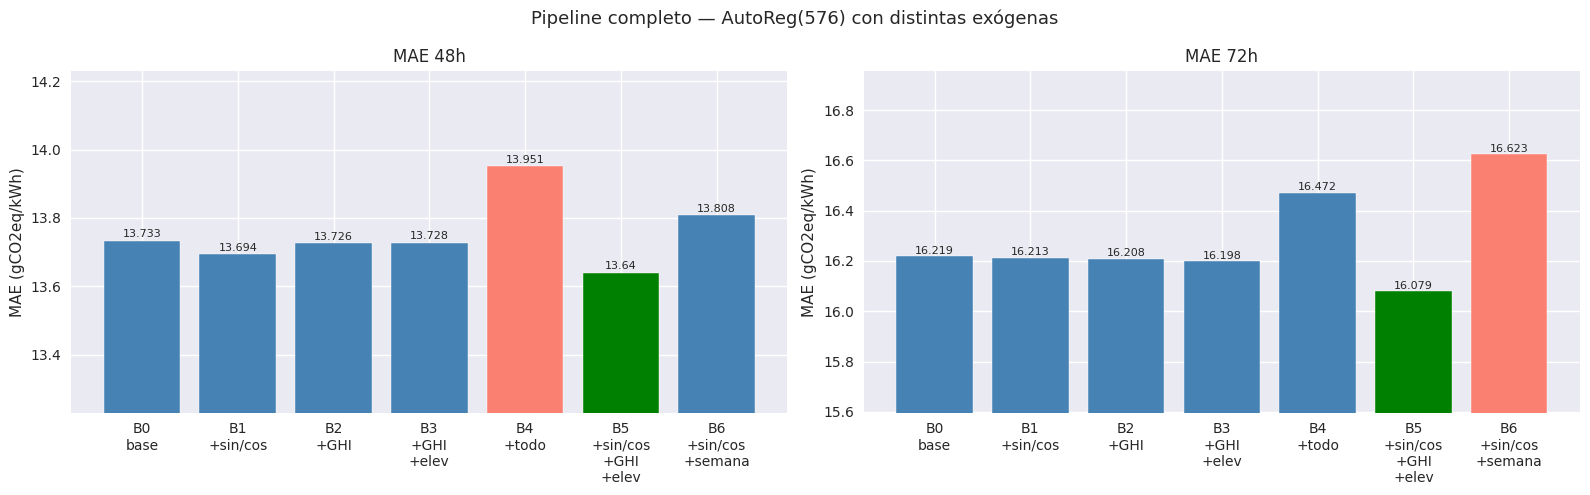

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Pipeline completo — AutoReg(576) con distintas exógenas", fontsize=13)

modelos = ["B0_base", "B1_sincos", "B2_ghi", "B3_ghi_elev",
           "B4_ghi_elev_azimuth", "B5_sincos_ghi_elev", "B6_sincos_week"]
etiquetas = ["B0\nbase", "B1\n+sin/cos", "B2\n+GHI",
             "B3\n+GHI\n+elev", "B4\n+GHI\n+elev\n+azimut",
             "B5\n+sin/cos\n+GHI\n+elev", "B6\n+sin/cos\n+semana"]

for ax, horizon in zip(axes, ["48h", "72h"]):
    mae_vals = [
        comparacion_completa[
            (comparacion_completa["model"] == m) &
            (comparacion_completa["horizon"] == horizon)
        ]["MAE"].values[0]
        for m in modelos
    ]
    colors = ["green" if v == min(mae_vals) else
              "salmon" if v == max(mae_vals) else
              "steelblue" for v in mae_vals]
    ax.bar(etiquetas, mae_vals, color=colors, edgecolor="white")
    ax.set_title(f"MAE {horizon}")
    ax.set_ylabel("MAE (gCO2eq/kWh)")
    ax.set_ylim(min(mae_vals) * 0.97, max(mae_vals) * 1.02)
    for i, v in enumerate(mae_vals):
        ax.text(i, v + 0.01, str(round(v, 3)), ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/autoreg_pipeline_completo.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. ¿Pueden las variables solares sustituir al sin/cos de la hora?

Los resultados muestran que las variables solares obtienen un
rendimiento prácticamente equivalente al sin/cos — diferencia
de solo 0.034 MAE a 48h, y superando al sin/cos a 72h
(B3: 16.198 vs B1: 16.213).

Desde el punto de vista numérico ambas aproximaciones son
equivalentes. Sin embargo existe una razón metodológica
importante para preferir las variables solares sobre el sin/cos:

El sin/cos de la hora es una transformación matemática arbitraria
que codifica la posición temporal de forma cíclica sin ninguna
relación causal con la variable objetivo. Las variables solares
en cambio tienen una motivación física directa — la irradiación
solar determina la generación fotovoltaica, que desplaza fuentes
más contaminantes del mix eléctrico reduciendo la huella de
carbono operacional.

Por tanto, aunque numéricamente la diferencia sea marginal,
el uso de GHI + elevación solar está físicamente justificado
y es metodológicamente más sólido que el sin/cos de la hora.


## 18. Visualización — modelo óptimo B3 y B5 vs real

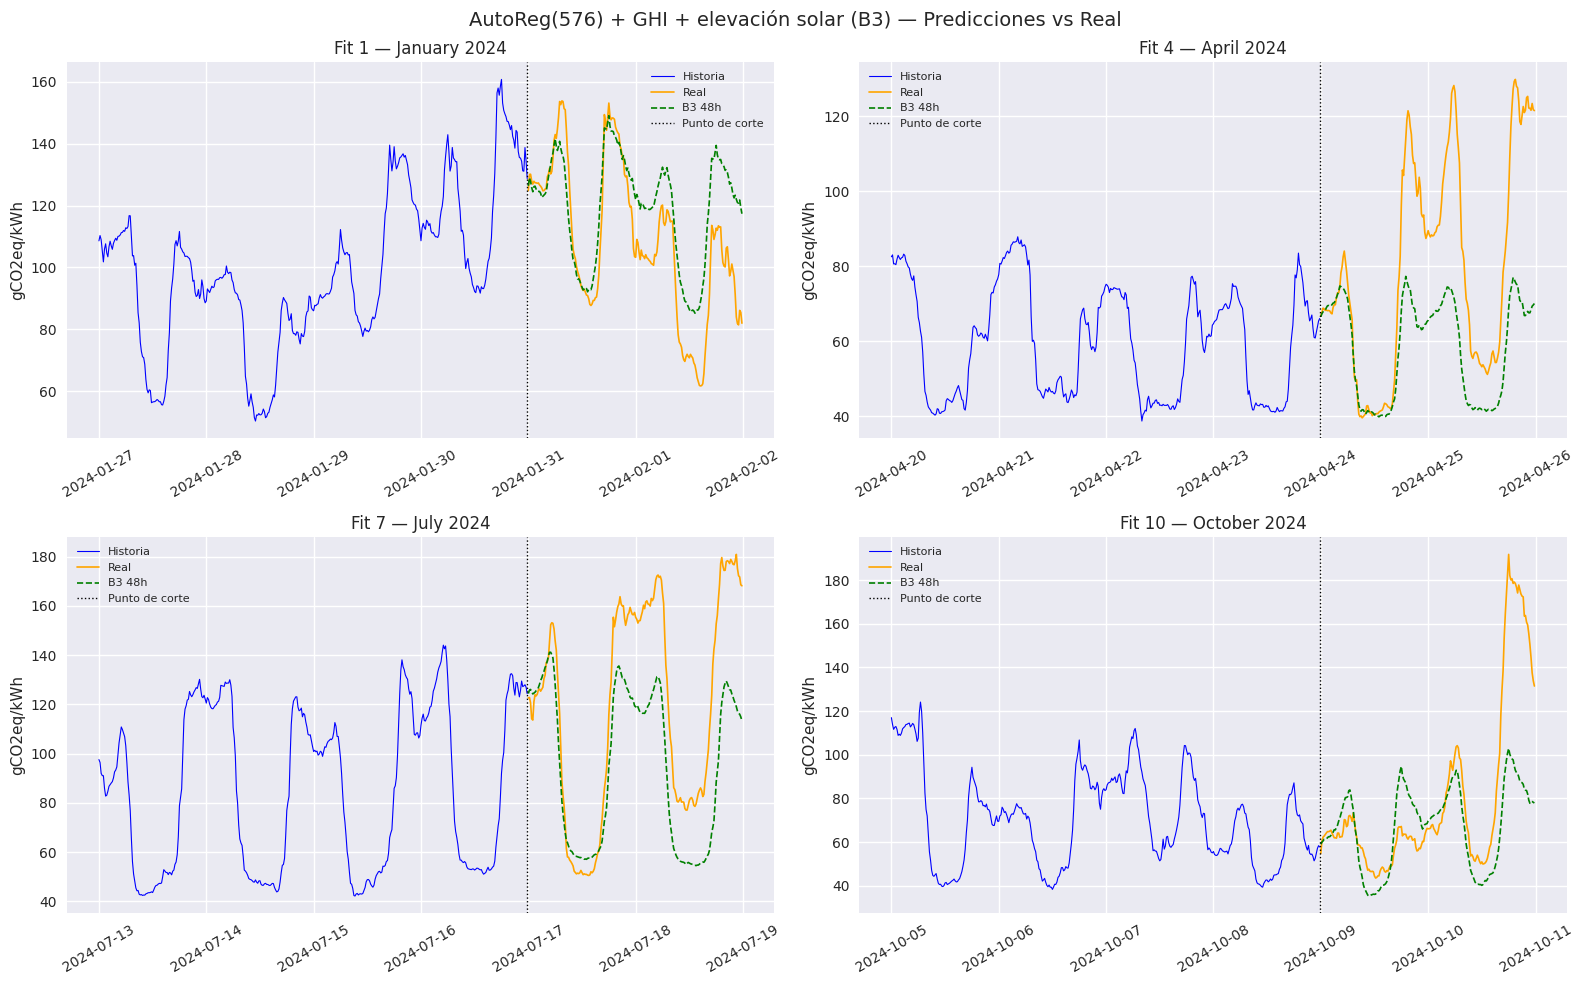

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("AutoReg(576) + GHI + elevación solar (B3) — Predicciones vs Real", fontsize=14)

preds_b3 = preds_store_pipeline["B3_ghi_elev"]

for idx, split_idx in enumerate([0, 3, 6, 9]):
    ax          = axes[idx // 2][idx % 2]
    fit         = preds_b3[split_idx]
    cutoff_time = fit["cutoff_time"]
    train_w     = fit["train_window"]
    test_48     = fit["48h"]["test"]
    pred_48     = fit["48h"]["pred"]

    history = train_w.iloc[-4 * SEASONAL_PERIOD:]
    ax.plot(history.index, history.values,
            color="blue", label="Historia", linewidth=0.8)
    ax.plot(test_48.index, test_48.values,
            color="orange", label="Real", linewidth=1.2)
    ax.plot(test_48.index, pred_48,
            color="green", linestyle="--", label="B3 48h", linewidth=1.2)
    ax.axvline(x=cutoff_time, color="black", linestyle=":",
               linewidth=1.0, label="Punto de corte")
    ax.set_title(f"Fit {split_idx+1} — {cutoff_time.strftime('%B %Y')}")
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/autoreg_b3_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()

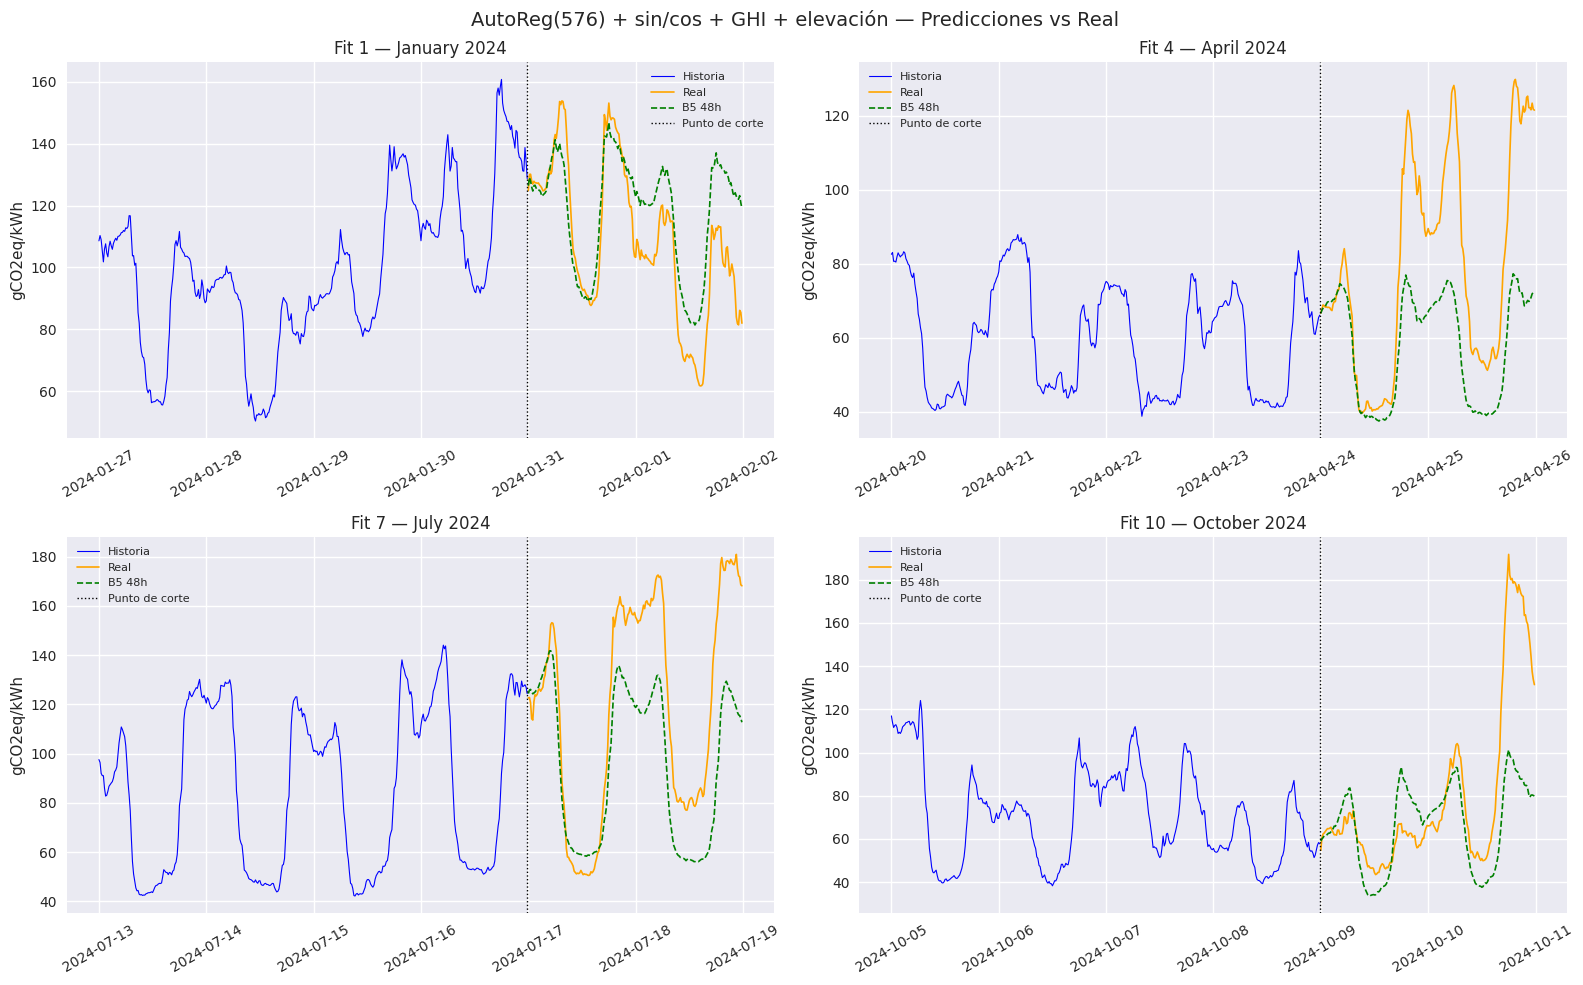

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("AutoReg(576) + sin/cos + GHI + elevación — Predicciones vs Real", fontsize=14)

preds_b5 = preds_store_pipeline["B5_sincos_ghi_elev"]

for idx, split_idx in enumerate([0, 3, 6, 9]):
    ax = axes[idx // 2][idx % 2]
    fit         = preds_b5[split_idx]
    cutoff_time = fit["cutoff_time"]
    train_w     = fit["train_window"]
    test_48     = fit["48h"]["test"]
    pred_48     = fit["48h"]["pred"]

    history = train_w.iloc[-4 * SEASONAL_PERIOD:]
    ax.plot(history.index, history.values,
            color="blue", label="Historia", linewidth=0.8)
    ax.plot(test_48.index, test_48.values,
            color="orange", label="Real", linewidth=1.2)
    ax.plot(test_48.index, pred_48,
            color="green", linestyle="--", label="B5 48h", linewidth=1.2)
    ax.axvline(x=cutoff_time, color="black", linestyle=":",
               linewidth=1.0, label="Punto de corte")
    ax.set_title(f"Fit {split_idx+1} — {cutoff_time.strftime('%B %Y')}")
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/autoreg_b5_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()

## 19. Modelo preferido — B3 vs B5

Aunque B5 obtiene el mejor MAE global, B3 (GHI + elevación sin
sin/cos) es metodológicamente preferible cuando el objetivo es
maximizar la interpretabilidad física del modelo.

B3 sustituye completamente el sin/cos — una codificación temporal
arbitraria — por variables con motivación física directa, obteniendo
un rendimiento prácticamente equivalente a 48h y superior a 72h.

En un contexto de producción donde la interpretabilidad y la
justificación física del modelo son importantes, B3 representa
la mejor solución al combinar buen rendimiento predictivo con
variables exógenas causalmente relacionadas con la variable objetivo.

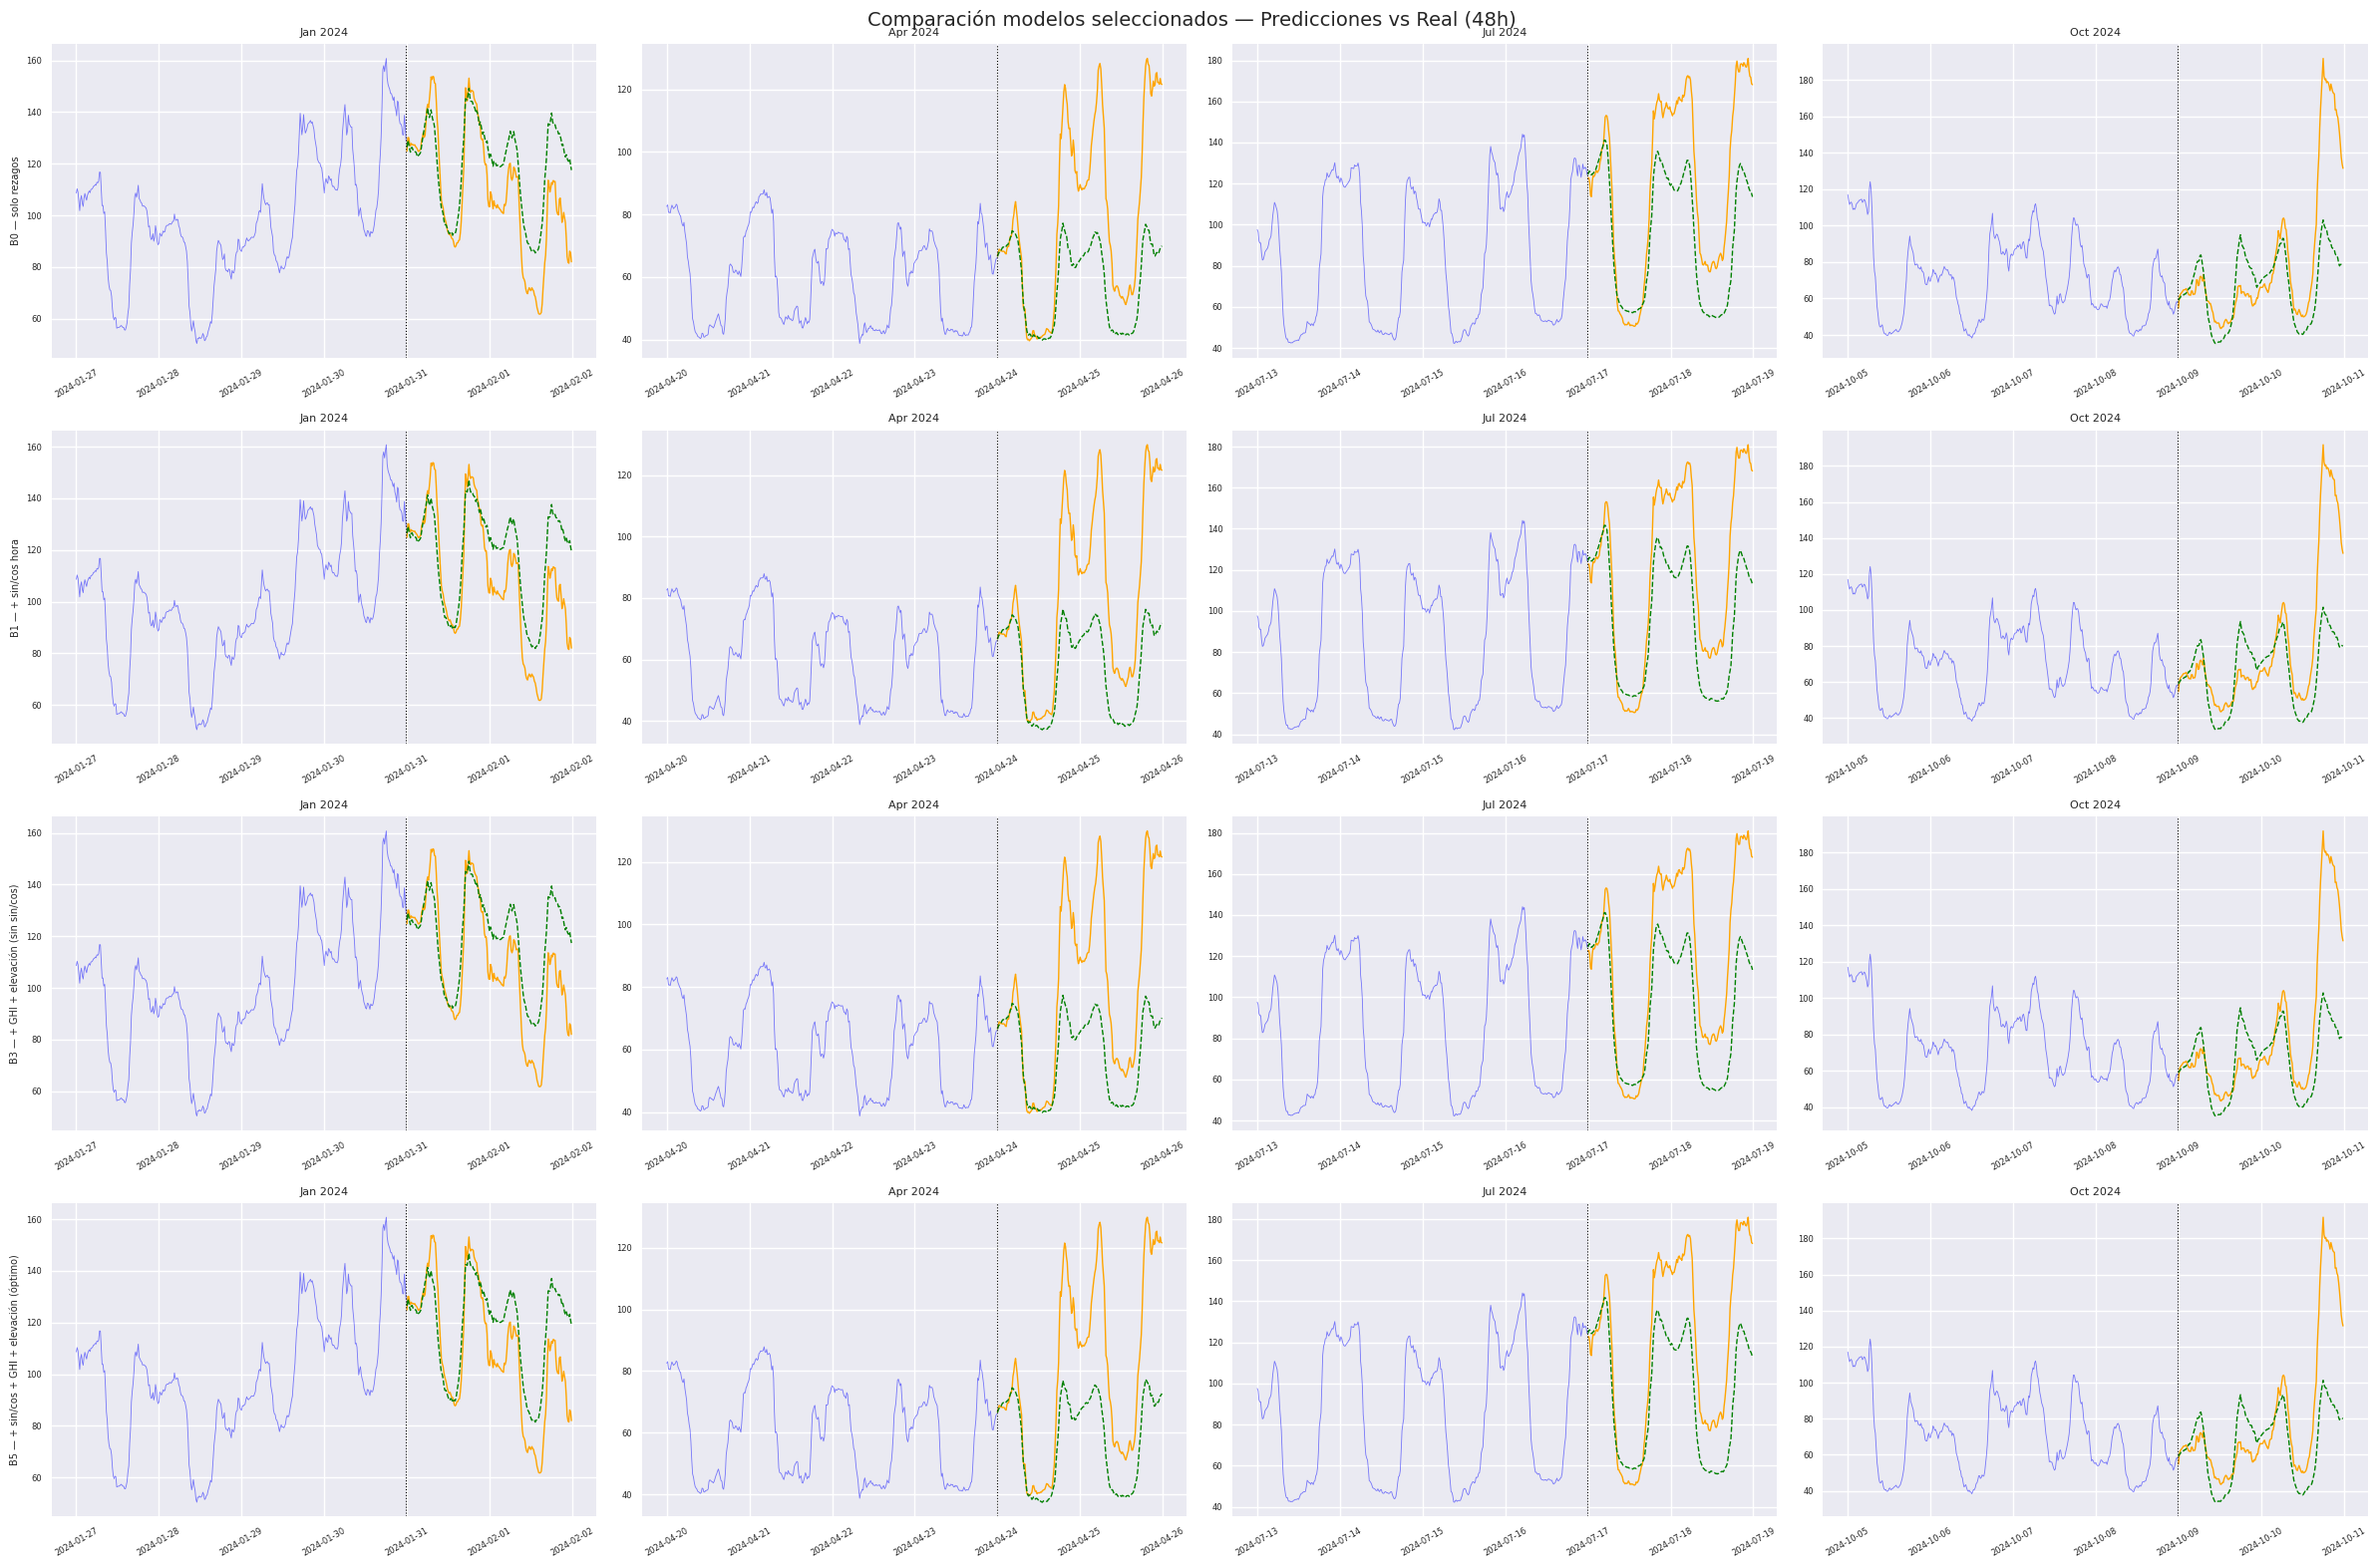

In [ ]:
modelos_plot = {
    "B0_base":           "B0 — solo rezagos",
    "B1_sincos":         "B1 — + sin/cos hora",
    "B3_ghi_elev":       "B3 — + GHI + elevación (sin sin/cos)",
    "B5_sincos_ghi_elev": "B5 — + sin/cos + GHI + elevación (óptimo)",
}

fig, axes = plt.subplots(4, 4, figsize=(24, 16))
fig.suptitle("Comparación modelos seleccionados — Predicciones vs Real (48h)", fontsize=14)

for row, (model_name, label) in enumerate(modelos_plot.items()):
    preds = preds_store_pipeline[model_name]
    for col, split_idx in enumerate([0, 3, 6, 9]):
        ax          = axes[row][col]
        fit         = preds[split_idx]
        cutoff_time = fit["cutoff_time"]
        train_w     = fit["train_window"]
        test_48     = fit["48h"]["test"]
        pred_48     = fit["48h"]["pred"]

        history = train_w.iloc[-4 * SEASONAL_PERIOD:]
        ax.plot(history.index, history.values,
                color="blue", linewidth=0.6, alpha=0.5)
        ax.plot(test_48.index, test_48.values,
                color="orange", linewidth=1.0, label="Real")
        ax.plot(test_48.index, pred_48,
                color="green", linestyle="--", linewidth=1.0)
        ax.axvline(x=cutoff_time, color="black", linestyle=":", linewidth=0.8)
        ax.set_title(f"{cutoff_time.strftime('%b %Y')}", fontsize=8)
        ax.tick_params(axis="x", rotation=30, labelsize=6)
        ax.tick_params(axis="y", labelsize=6)
        if col == 0:
            ax.set_ylabel(label, fontsize=7)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/autoreg_modelos_seleccionados.png", dpi=150, bbox_inches="tight")
plt.show()

## 20. Conclusiones finales

El análisis progresivo de variables exógenas sobre AutoReg(576)
permite concluir que las variables solares (GHI + elevación)
constituyen una alternativa sólida al sin/cos de la hora como
codificación temporal.

Los resultados numéricos muestran que B3 (GHI + elevación sin
sin/cos) obtiene MAE 13.728 a 48h y 16.198 a 72h, frente a
13.694 y 16.213 del modelo con sin/cos (B1). La diferencia a
48h es de solo 0.034 gCO2eq/kWh — prácticamente insignificante
— y a 72h las variables solares superan al sin/cos.

Esta equivalencia numérica, combinada con la motivación física
de las variables solares, justifica su uso en lugar del sin/cos:

- El sin/cos es una transformación matemática arbitraria sin
  relación causal con la huella de carbono.
- GHI y elevación solar tienen una relación física directa —
  la irradiación solar determina la generación fotovoltaica,
  que desplaza fuentes más contaminantes del mix eléctrico.

El modelo **B3: AutoReg(576) + GHI + elevación solar** se
establece como el modelo estadístico de referencia del TFM
por combinar buen rendimiento predictivo con variables exógenas
físicamente motivadas y causalmente relacionadas con la variable
objetivo.

El modelo B5 (sin/cos + GHI + elevación) obtiene el mejor MAE
global (13.640 a 48h) al combinar ambas fuentes de información,
pero a costa de incluir el sin/cos cuya justificación física
es más débil.

Estos resultados sientan las bases para el siguiente paso del
TFM — las redes neuronales recurrentes (RNN y LSTM) — donde
se explorará si modelos no lineales con mayor capacidad expresiva
pueden mejorar significativamente estos resultados utilizando
las mismas variables exógenas físicamente motivadas.

## 22. Comparación global — todos los modelos del TFM

In [ ]:
# Cargar resultados anteriores
naive_arima  = pd.read_csv(RESULTS_DIR / "comparacion_naive_arima.csv")
sarima       = pd.read_csv(RESULTS_DIR / "sarima_summary.csv")

# Modelos anteriores
anteriores = pd.concat([naive_arima, sarima], ignore_index=True)

# Pipeline actual — ya en comparacion_completa
pipeline = comparacion_completa.copy()

# Combinar todo
comparacion_final = pd.concat([anteriores, pipeline], ignore_index=True)
comparacion_final["MAE"]  = comparacion_final["MAE"].round(3)
comparacion_final["RMSE"] = comparacion_final["RMSE"].round(3)
comparacion_final = comparacion_final.drop_duplicates(subset=["model", "horizon"])

tabla_final = comparacion_final.pivot_table(
    index="model",
    columns="horizon",
    values=["MAE", "RMSE"]
).round(3).sort_values(("MAE", "48h"))

print(tabla_final)
comparacion_final.to_csv(RESULTS_DIR / "comparacion_global.csv", index=False)

                                  MAE            RMSE        
horizon                           48h     72h     48h     72h
model                                                        
B5_sincos_ghi_elev             13.640  16.079  17.900  20.778
B1_sincos                      13.694  16.213  17.991  20.954
B2_ghi                         13.726  16.208  18.077  21.017
B3_ghi_elev                    13.728  16.198  18.063  20.998
B0_base                        13.733  16.219  18.085  21.028
B6_sincos_week                 13.808  16.623  17.988  21.307
B4_all                         13.951  16.472  18.100  21.061
Naive_seasonal                 18.302  19.662  22.742  24.617
SARIMA(1, 1, 0)x(1, 0, 0, 96)  25.201  29.039  31.023  35.113
ARIMA(5,1,0)                   27.155  28.061  33.796  34.877
Naive_last                     27.914  29.777  33.984  35.971


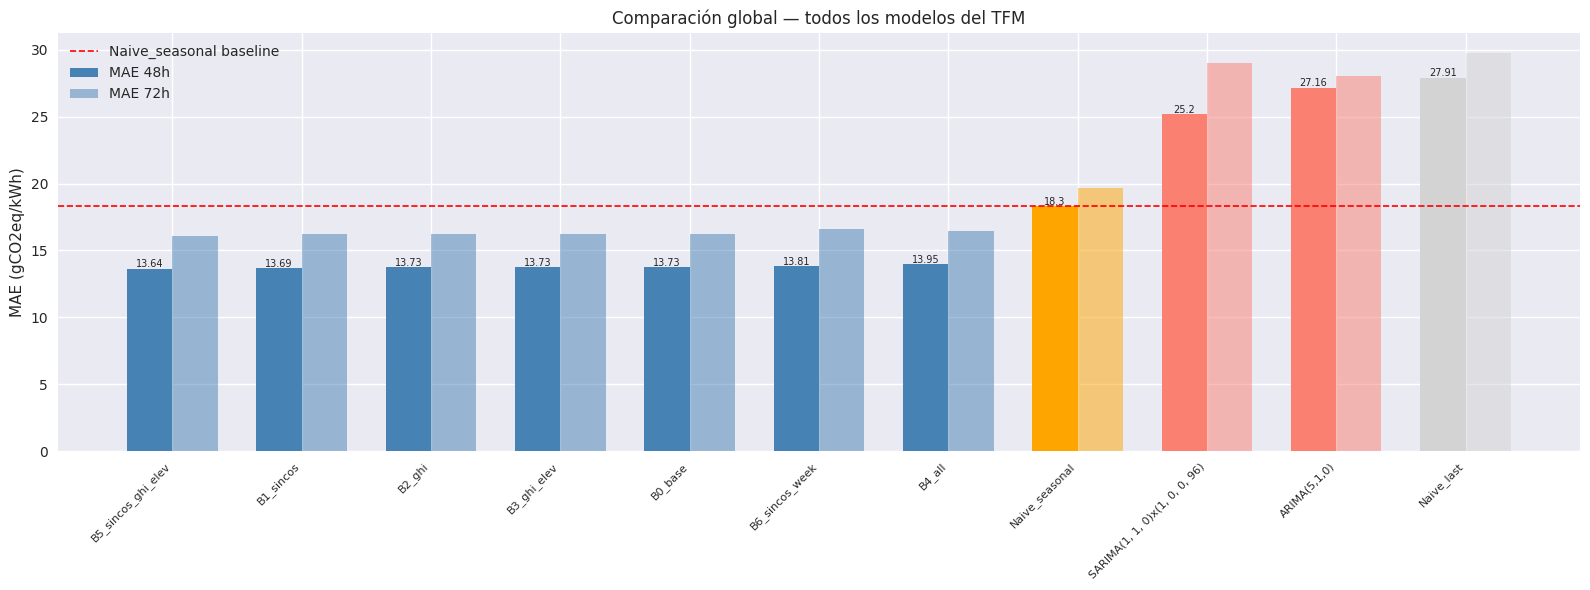

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

modelos_order = tabla_final.index.tolist()
mae_48 = tabla_final[("MAE", "48h")].values
mae_72 = tabla_final[("MAE", "72h")].values

x     = np.arange(len(modelos_order))
width = 0.35

# Colores — verde para AutoReg, azul para baselines, rojo para ARIMA/SARIMA
colors_48 = []
for m in modelos_order:
    if m.startswith("B"):
        colors_48.append("steelblue")
    elif m == "Naive_seasonal":
        colors_48.append("orange")
    elif m.startswith("ARIMA") or m.startswith("SARIMA"):
        colors_48.append("salmon")
    else:
        colors_48.append("lightgray")

ax.bar(x - width/2, mae_48, width, label="MAE 48h", color=colors_48)
ax.bar(x + width/2, mae_72, width, label="MAE 72h",
       color=[c for c in colors_48], alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(modelos_order, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("MAE (gCO2eq/kWh)")
ax.set_title("Comparación global — todos los modelos del TFM")
ax.axhline(y=18.302, color="red", linestyle="--",
           linewidth=1.2, label="Naive_seasonal baseline")
ax.legend()

for i, v in enumerate(mae_48):
    ax.text(i - width/2, v + 0.1, str(round(v, 2)), ha="center", fontsize=7)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/comparacion_global.png", dpi=150, bbox_inches="tight")
plt.show()

## 23. Conclusiones finales — comparación global

El gráfico comparativo muestra claramente tres grupos de modelos:

**Grupo 1 — Modelos estadísticos clásicos (por encima del baseline):**
ARIMA(5,1,0), SARIMA(1,1,0)(1,0,0)[96] y Naive_last no superan al
Naive_seasonal. ARIMA y SARIMA colapsan a la media para horizontes
largos debido a su limitada memoria, confirmando que los modelos
clásicos con pocos órdenes son insuficientes para horizontes de
48h y 72h en series con fuerte estacionalidad diaria.

**Grupo 2 — Naive_seasonal (baseline principal):**
Con MAE 18.30 a 48h es la referencia mínima que cualquier modelo
más complejo debe superar. Su buen rendimiento refleja la fuerte
estacionalidad diaria de la serie.

**Grupo 3 — AutoReg con distintas exógenas (todos superan el baseline):**
Todos los modelos del pipeline B superan al Naive_seasonal,
reduciendo el MAE entre un 24% y un 25.5%. Las diferencias
entre configuraciones son pequeñas — el modelo base B0 sin
ninguna exógena ya obtiene MAE 13.733, y el mejor modelo B5
obtiene 13.640.

### Variable más útil — GHI

El GHI es la variable exógena que más aporta individualmente.
La elevación solar añade una mejora marginal a 72h pero prácticamente
nula a 48h. El azimut y el sin/cos del día de la semana empeoran
el modelo y se descartan.

### Sin/cos vs variables solares

El sin/cos de la hora obtiene un MAE ligeramente mejor a 48h
(diferencia de 0.034) pero las variables solares lo superan a 72h.
Dado que la diferencia es insignificante operativamente, el uso
de GHI + elevación solar está metodológicamente justificado por
su motivación física directa — la irradiación solar tiene una
relación causal con la huella de carbono a través de la generación
fotovoltaica, algo que el sin/cos no puede afirmar.

### Modelo de referencia estadístico

El modelo **B3: AutoReg(576) + GHI + elevación solar** se establece
como modelo estadístico de referencia del TFM por combinar buen
rendimiento predictivo (MAE 13.728 a 48h, 16.198 a 72h) con
variables exógenas físicamente motivadas y causalmente relacionadas
con la variable objetivo.

Estos resultados sientan las bases para el siguiente paso —
redes neuronales recurrentes (RNN y LSTM) — donde se explorará
si modelos no lineales con mayor capacidad expresiva pueden
mejorar significativamente estos resultados.

## Temperatura como variable exógena

Se descarga la temperatura horaria para España desde Open-Meteo
(2005-2023) y se construye un perfil climatológico medio igual
que con GHI y elevación solar.

La temperatura está relacionada causalmente con la huella de
carbono — en invierno la mayor demanda de calefacción aumenta
el consumo eléctrico y puede incrementar la huella si se usan
fuentes más contaminantes.

In [ ]:
import requests
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("/home/ubuntu/TFM/notebooks/data_processed")

def download_temperature(lat, lon, start_year, end_year):
    frames = []
    for year in range(start_year, end_year + 1):
        print(f"Descargando temperatura {year}...")
        url = (
            f"https://archive-api.open-meteo.com/v1/archive?"
            f"latitude={lat}&longitude={lon}"
            f"&start_date={year}-01-01&end_date={year}-12-31"
            f"&hourly=temperature_2m"
            f"&timezone=UTC"
        )
        r = requests.get(url)
        data = r.json()
        df = pd.DataFrame({
            "timestamp": pd.to_datetime(data["hourly"]["time"]),
            "temperature": data["hourly"]["temperature_2m"]
        })
        df = df.set_index("timestamp")
        frames.append(df)
    return pd.concat(frames)

LAT, LON = 40.4, -3.7
temp_historico = download_temperature(LAT, LON, 2005, 2023)
print("\nTemperatura descargada:", temp_historico.shape)
print(temp_historico.head())

Descargando temperatura 2005...
Descargando temperatura 2006...
Descargando temperatura 2007...
Descargando temperatura 2008...
Descargando temperatura 2009...
Descargando temperatura 2010...
Descargando temperatura 2011...
Descargando temperatura 2012...
Descargando temperatura 2013...
Descargando temperatura 2014...
Descargando temperatura 2015...


Descargando temperatura 2016...
Descargando temperatura 2017...
Descargando temperatura 2018...
Descargando temperatura 2019...
Descargando temperatura 2020...
Descargando temperatura 2021...
Descargando temperatura 2022...
Descargando temperatura 2023...

Temperatura descargada: (166536, 1)
                     temperature
timestamp                       
2005-01-01 00:00:00          2.1
2005-01-01 01:00:00          1.8
2005-01-01 02:00:00          1.7
2005-01-01 03:00:00          1.5
2005-01-01 04:00:00          1.4


### Perfil climatológico medio 2005-2023

Se calcula la temperatura media por (mes, día, hora) sobre los
19 años históricos — igual que con GHI.

In [ ]:
# Perfil climatológico medio
temp_historico.index = temp_historico.index.tz_localize("UTC")
temp_historico["mes"]  = temp_historico.index.month
temp_historico["dia"]  = temp_historico.index.day
temp_historico["hora"] = temp_historico.index.hour

perfil_temp = (
    temp_historico
    .groupby(["mes", "dia", "hora"])["temperature"]
    .mean()
    .reset_index()
)

print("Perfil climatológico temperatura:", perfil_temp.shape)
print(perfil_temp.head())

Perfil climatológico temperatura: (8784, 4)
   mes  dia  hora  temperature
0    1    1     0     3.289474
1    1    1     1     3.036842
2    1    1     2     2.763158
3    1    1     3     2.531579
4    1    1     4     2.378947


### Interpolación horaria a 15 minutos

La temperatura descargada tiene resolución horaria. Para alinearla
con la serie de huella de carbono (15 minutos) se interpola
linealmente entre cada par de valores horarios consecutivos.

Es metodológicamente correcto para la temperatura porque es una
variable continua que cambia suavemente — la interpolación lineal
entre 14:00 y 15:00 es una buena aproximación del valor real
a las 14:15, 14:30 y 14:45.

In [ ]:
# Construir índice horario 2022-2025
idx_horario = pd.date_range(
    start="2022-01-01", end="2025-12-31 23:00", freq="1h", tz="UTC"
)

df_idx = pd.DataFrame({
    "mes":  idx_horario.month,
    "dia":  idx_horario.day,
    "hora": idx_horario.hour
}, index=idx_horario)

# Unir con perfil climatológico
temp_clima = df_idx.merge(perfil_temp, on=["mes", "dia", "hora"], how="left")
temp_clima.index = idx_horario
temp_clima = temp_clima[["temperature"]]

# Interpolación horaria → 15min
idx_15min = pd.date_range(
    start="2022-01-01", end="2025-12-31 23:45", freq="15min", tz="UTC"
)
temp_15min = temp_clima.reindex(
    temp_clima.index.union(idx_15min)
).interpolate(method="time").reindex(idx_15min)

print("Temperatura 15min:", temp_15min.shape)
print(temp_15min.head())

Temperatura 15min: (140256, 1)
                           temperature
2022-01-01 00:00:00+00:00     3.289474
2022-01-01 00:15:00+00:00     3.226316
2022-01-01 00:30:00+00:00     3.163158
2022-01-01 00:45:00+00:00     3.100000
2022-01-01 01:00:00+00:00     3.036842


### Actualización del parquet de exógenas

In [ ]:
# Cargar exógenas existentes
exogenas = pd.read_parquet(DATA_DIR / "exogenas_15min.parquet")
exogenas.index = pd.to_datetime(exogenas.index)

# Añadir temperatura
exogenas["temperature"] = temp_15min["temperature"].values

print("Exógenas actualizadas:", exogenas.shape)
print(exogenas.columns.tolist())
print(exogenas.head())

# Verificar NaN
print("\nNaN por columna:")
print(exogenas.isna().sum())

# Guardar
exogenas.to_parquet(DATA_DIR / "exogenas_15min.parquet")
print("\nGuardado OK")

Exógenas actualizadas: (140256, 4)
['ghi', 'solar_elevation', 'solar_azimuth', 'temperature']
                           ghi  solar_elevation  solar_azimuth  temperature
2022-01-01 00:00:00+00:00  0.0              0.0       9.100462     3.289474
2022-01-01 00:15:00+00:00  0.0              0.0       9.100462     3.226316
2022-01-01 00:30:00+00:00  0.0              0.0       9.100462     3.163158
2022-01-01 00:45:00+00:00  0.0              0.0      18.443224     3.100000
2022-01-01 01:00:00+00:00  0.0              0.0      27.785985     3.036842

NaN por columna:
ghi                0
solar_elevation    0
solar_azimuth      0
temperature        0
dtype: int64

Guardado OK


## 23. Temperatura como variable exógena

Se añade la temperatura media climatológica 2005-2023 como variable
exógena adicional para evaluar su contribución sobre el mejor
modelo actual.

La temperatura tiene una relación causal con la huella de carbono
— en invierno la mayor demanda de calefacción eléctrica incrementa
el consumo y puede aumentar la huella si se activan fuentes más
contaminantes del mix eléctrico.

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg

warnings.filterwarnings("ignore")

BASE_DIR    = Path("/home/ubuntu/TFM")
DATA_DIR    = BASE_DIR / "notebooks/data_processed"
RESULTS_DIR = BASE_DIR / "results"

FREQ_MIN        = 15
STEPS_PER_HOUR  = 60 // FREQ_MIN
SEASONAL_PERIOD = 24 * STEPS_PER_HOUR
LAGS_OPT_B0     = 576

HORIZONS = {
    "48h": 48 * STEPS_PER_HOUR,
    "72h": 72 * STEPS_PER_HOUR,
}

@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

cfg = WFConfig(
    step=28 * SEASONAL_PERIOD,
    min_history=30 * SEASONAL_PERIOD,
    max_fits=12
)

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

def summarize(df, model_name):
    out = (
        df.groupby("horizon")[["MAE", "RMSE"]]
        .mean()
        .reset_index()
    )
    out.insert(0, "model", model_name)
    return out

def make_cyclic_features(index, interval_minutes=15):
    slots_per_day = int(24 * 60 / interval_minutes)
    slot = (index.hour * 60 + index.minute) // interval_minutes
    sin  = np.sin(2 * np.pi * slot / slots_per_day)
    cos  = np.cos(2 * np.pi * slot / slots_per_day)
    return pd.DataFrame({"slot_sin": sin, "slot_cos": cos}, index=index)

def forecast_autoreg(train, train_exog, future_exog, h, lags):
    model = AutoReg(train.values, lags=lags, trend="n", exog=train_exog)
    model_fit = model.fit()
    n     = len(train)
    preds = model_fit.predict(
        start=n, end=n + h - 1,
        dynamic=False, exog_oos=future_exog
    )
    return preds

def walk_forward_splits(series, horizons, cfg):
    n      = len(series)
    max_h  = max(horizons.values())
    points = list(range(cfg.min_history, n - max_h, cfg.step))
    points = points[:cfg.max_fits]
    for t0 in points:
        train_part = series.iloc[:t0]
        tests = {k: series.iloc[t0:t0 + h] for k, h in horizons.items()}
        yield train_part, tests

def evaluate_autoreg(y_train, y_val, exog_full, horizons, cfg, lags, verbose=True):
    rows        = []
    preds_store = []
    y_full  = pd.concat([y_train, y_val]).sort_index()
    n_train = len(y_train)
    splits  = list(walk_forward_splits(y_val, horizons, cfg))
    total   = len(splits)

    for i, (train_part, tests) in enumerate(splits, 1):
        if verbose:
            print(f"Fit {i}/{total}")
        cutoff_idx   = n_train + len(train_part)
        cutoff_time  = y_full.index[cutoff_idx - 1]
        train_window = y_full.iloc[:cutoff_idx]
        train_exog_w = exog_full.iloc[:cutoff_idx] if exog_full is not None else None

        fit_preds = {"cutoff_time": cutoff_time, "train_window": train_window}
        for name, test in tests.items():
            h           = len(test)
            future_exog = exog_full.iloc[cutoff_idx:cutoff_idx + h] if exog_full is not None else None
            pred        = forecast_autoreg(train_window, train_exog_w, future_exog, h, lags)
            m           = compute_metrics(test.values, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})
            fit_preds[name] = {"pred": pred, "test": test}
        preds_store.append(fit_preds)

    return pd.DataFrame(rows), preds_store

print("Funciones cargadas OK")

Funciones cargadas OK


In [ ]:
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_train.index = pd.to_datetime(y_train.index)
y_val.index   = pd.to_datetime(y_val.index)

exogenas = pd.read_parquet(DATA_DIR / "exogenas_15min.parquet")
exogenas.index = pd.to_datetime(exogenas.index)

y_full_index = y_train.index.append(y_val.index)
cyclic = make_cyclic_features(y_full_index)
solar  = exogenas.loc[y_full_index]

exog_temp = {
    "B7_ghi_elev_temp":        solar[["ghi", "solar_elevation", "temperature"]],
    "B8_sincos_ghi_elev_temp": pd.concat([cyclic, solar[["ghi", "solar_elevation", "temperature"]]], axis=1),
}

for name, exog in exog_temp.items():
    print(f"{name}: {exog.columns.tolist()}")

B7_ghi_elev_temp: ['ghi', 'solar_elevation', 'temperature']
B8_sincos_ghi_elev_temp: ['slot_sin', 'slot_cos', 'ghi', 'solar_elevation', 'temperature']


In [ ]:
resultados_temp = []

for model_name, exog in exog_temp.items():
    print(f"\nEvaluando {model_name}...")
    df_res, _ = evaluate_autoreg(
        y_train, y_val,
        exog, HORIZONS, cfg,
        lags=LAGS_OPT_B0,
        verbose=False
    )
    summary = summarize(df_res, model_name)
    resultados_temp.append(summary)
    print(summary)

comparacion_temp = pd.concat(resultados_temp, ignore_index=True)
print("\n--- COMPARACIÓN CON TEMPERATURA ---")
print(comparacion_temp)
comparacion_temp.to_csv(RESULTS_DIR / "autoreg_temperatura.csv", index=False)


Evaluando B7_ghi_elev_temp...


              model horizon        MAE       RMSE
0  B7_ghi_elev_temp     48h  13.609377  17.640548
1  B7_ghi_elev_temp     72h  15.662070  19.933840

Evaluando B8_sincos_ghi_elev_temp...
                     model horizon        MAE       RMSE
0  B8_sincos_ghi_elev_temp     48h  13.631923  17.606216
1  B8_sincos_ghi_elev_temp     72h  15.754137  19.992316

--- COMPARACIÓN CON TEMPERATURA ---
                     model horizon        MAE       RMSE
0         B7_ghi_elev_temp     48h  13.609377  17.640548
1         B7_ghi_elev_temp     72h  15.662070  19.933840
2  B8_sincos_ghi_elev_temp     48h  13.631923  17.606216
3  B8_sincos_ghi_elev_temp     72h  15.754137  19.992316


In [ ]:
exog_temp_extra = {
    "B9_temp":          solar[["temperature"]],
    "B10_ghi_temp":     solar[["ghi", "temperature"]],
}

for name, exog in exog_temp_extra.items():
    print(f"{name}: {exog.columns.tolist()}")

B9_temp: ['temperature']
B10_ghi_temp: ['ghi', 'temperature']


In [ ]:
for model_name, exog in exog_temp_extra.items():
    print(f"\nEvaluando {model_name}...")
    df_res, _ = evaluate_autoreg(
        y_train, y_val,
        exog, HORIZONS, cfg,
        lags=LAGS_OPT_B0,
        verbose=False
    )
    summary = summarize(df_res, model_name)
    resultados_temp.append(summary)
    print(summary)

comparacion_temp_completa = pd.concat(resultados_temp, ignore_index=True)
print("\n--- COMPARACIÓN COMPLETA CON TEMPERATURA ---")
tabla = comparacion_temp_completa.pivot_table(
    index="model",
    columns="horizon",
    values=["MAE", "RMSE"]
).round(3).sort_values(("MAE", "48h"))
print(tabla)
comparacion_temp_completa.to_csv(RESULTS_DIR / "autoreg_temperatura_completa.csv", index=False)


Evaluando B9_temp...
     model horizon        MAE       RMSE
0  B9_temp     48h  13.539955  17.667709
1  B9_temp     72h  15.567602  19.968960

Evaluando B10_ghi_temp...
          model horizon        MAE       RMSE
0  B10_ghi_temp     48h  13.610696  17.677938
1  B10_ghi_temp     72h  15.723169  20.019378

--- COMPARACIÓN COMPLETA CON TEMPERATURA ---
                            MAE            RMSE        
horizon                     48h     72h     48h     72h
model                                                  
B9_temp                  13.540  15.568  17.668  19.969
B7_ghi_elev_temp         13.609  15.662  17.641  19.934
B10_ghi_temp             13.611  15.723  17.678  20.019
B8_sincos_ghi_elev_temp  13.632  15.754  17.606  19.992


In [ ]:
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/home/ubuntu/TFM/results")

import os
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f)

arima_summary.csv
autoreg_b0_lags_search.csv
autoreg_exogenas_comparacion.csv
autoreg_exogenas_pipeline.csv
autoreg_lags_search.csv
autoreg_pipeline_b.csv
autoreg_pipeline_completo.csv
autoreg_summary.csv
autoreg_temperatura.csv
autoreg_temperatura_completa.csv
comparacion_global.csv
comparacion_naive_arima.csv
comparacion_naive_arima_sarima.csv
comparacion_todos_estadisticos.csv
naive_arima_summary.csv
naive_summary.csv
prophet_summary.csv
rnn_summary.csv
sarima_summary.csv


## Comparación completa — todos los modelos

In [ ]:
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/home/ubuntu/TFM/results")

# Cargar todos los resultados
naive        = pd.read_csv(RESULTS_DIR / "naive_summary.csv")
arima        = pd.read_csv(RESULTS_DIR / "arima_summary.csv")
sarima       = pd.read_csv(RESULTS_DIR / "sarima_summary.csv")
autoreg      = pd.read_csv(RESULTS_DIR / "autoreg_summary.csv")
pipeline     = pd.read_csv(RESULTS_DIR / "autoreg_pipeline_completo.csv")
temperatura  = pd.read_csv(RESULTS_DIR / "autoreg_temperatura_completa.csv")
prophet      = pd.read_csv(RESULTS_DIR / "prophet_summary.csv")
rnn          = pd.read_csv(RESULTS_DIR / "rnn_summary.csv")

# Combinar todo
todos = pd.concat([
    naive, arima, sarima, autoreg,
    pipeline, temperatura, prophet, rnn
], ignore_index=True)

todos = todos.drop_duplicates(subset=["model", "horizon"])
todos["MAE"]  = todos["MAE"].round(3)
todos["RMSE"] = todos["RMSE"].round(3)

tabla = todos.pivot_table(
    index="model",
    columns="horizon",
    values=["MAE", "RMSE"]
).round(3).sort_values(("MAE", "48h"))

print(tabla)
todos.to_csv(RESULTS_DIR / "comparacion_todos.csv", index=False)

                                  MAE            RMSE        
horizon                           48h     72h     48h     72h
model                                                        
B9_temp                        13.540  15.568  17.668  19.969
B7_ghi_elev_temp               13.609  15.662  17.641  19.934
B10_ghi_temp                   13.611  15.723  17.678  20.019
B8_sincos_ghi_elev_temp        13.632  15.754  17.606  19.992
B5_sincos_ghi_elev             13.640  16.079  17.900  20.778
AutoReg(576)                   13.694  16.213  17.991  20.954
B1_sincos                      13.694  16.213  17.991  20.954
B2_ghi                         13.726  16.208  18.077  21.017
B3_ghi_elev                    13.728  16.198  18.063  20.998
B0_base                        13.733  16.219  18.085  21.028
B6_sincos_week                 13.808  16.623  17.988  21.307
B4_all                         13.951  16.472  18.100  21.061
RNN                            16.276  23.050  20.909  27.564
Naive_se

In [ ]:
# Modelos AutoReg con exógenas más representativos
modelos_autoreg = [
    "B0_base",              # solo rezagos
    "B1_sincos",            # + sin/cos hora
    "B3_ghi_elev",          # + GHI + elevación (sin sin/cos)
    "B9_temp",              # + solo temperatura (mejor modelo)
    "B7_ghi_elev_temp",     # + GHI + elevación + temperatura
    "B5_sincos_ghi_elev",   # + sin/cos + GHI + elevación
    "B8_sincos_ghi_elev_temp", # todo junto
]

tabla_autoreg = todos[todos["model"].isin(modelos_autoreg)].pivot_table(
    index="model",
    columns="horizon",
    values=["MAE", "RMSE"]
).round(3).sort_values(("MAE", "48h"))

print(tabla_autoreg)

                            MAE            RMSE        
horizon                     48h     72h     48h     72h
model                                                  
B9_temp                  13.540  15.568  17.668  19.969
B7_ghi_elev_temp         13.609  15.662  17.641  19.934
B8_sincos_ghi_elev_temp  13.632  15.754  17.606  19.992
B5_sincos_ghi_elev       13.640  16.079  17.900  20.778
B1_sincos                13.694  16.213  17.991  20.954
B3_ghi_elev              13.728  16.198  18.063  20.998
B0_base                  13.733  16.219  18.085  21.028


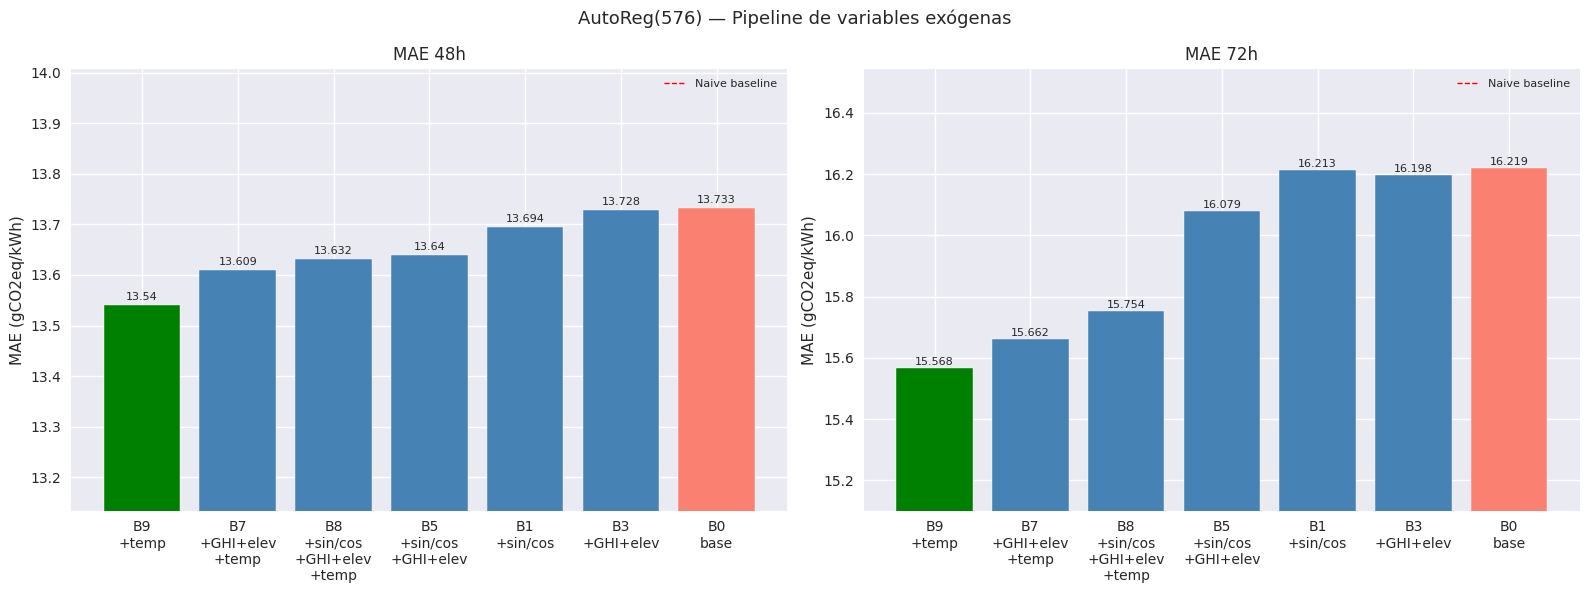

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("AutoReg(576) — Pipeline de variables exógenas", fontsize=13)

etiquetas = {
    "B0_base":               "B0\nbase",
    "B1_sincos":             "B1\n+sin/cos",
    "B3_ghi_elev":           "B3\n+GHI+elev",
    "B9_temp":               "B9\n+temp",
    "B7_ghi_elev_temp":      "B7\n+GHI+elev\n+temp",
    "B5_sincos_ghi_elev":    "B5\n+sin/cos\n+GHI+elev",
    "B8_sincos_ghi_elev_temp": "B8\n+sin/cos\n+GHI+elev\n+temp",
}

modelos_order = tabla_autoreg.index.tolist()
labels = [etiquetas[m] for m in modelos_order]

for ax, horizon in zip(axes, ["48h", "72h"]):
    mae_vals = tabla_autoreg[("MAE", horizon)].values
    colors = ["green" if v == min(mae_vals) else
              "salmon" if v == max(mae_vals) else
              "steelblue" for v in mae_vals]
    bars = ax.bar(labels, mae_vals, color=colors, edgecolor="white")
    ax.set_title(f"MAE {horizon}")
    ax.set_ylabel("MAE (gCO2eq/kWh)")
    ax.set_ylim(min(mae_vals) * 0.97, max(mae_vals) * 1.02)
    for i, v in enumerate(mae_vals):
        ax.text(i, v + 0.01, str(round(v, 3)),
                ha="center", fontsize=8)
    ax.axhline(y=18.302, color="red", linestyle="--",
               linewidth=1.0, label="Naive baseline")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/autoreg_exogenas_slides.png",
            dpi=150, bbox_inches="tight")
plt.show()

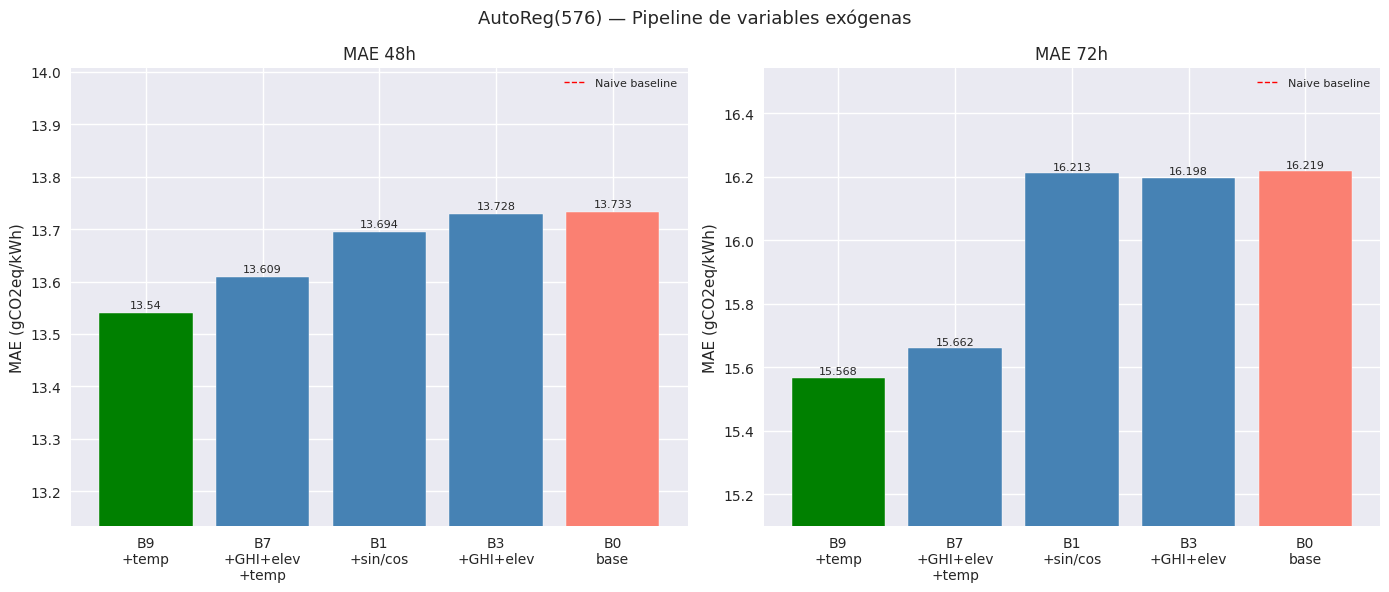

In [ ]:
modelos_autoreg = [
    "B0_base",
    "B1_sincos",
    "B3_ghi_elev",
    "B9_temp",
    "B7_ghi_elev_temp",
]

tabla_autoreg = todos[todos["model"].isin(modelos_autoreg)].pivot_table(
    index="model",
    columns="horizon",
    values=["MAE", "RMSE"]
).round(3).sort_values(("MAE", "48h"))

etiquetas = {
    "B0_base":          "B0\nbase",
    "B1_sincos":        "B1\n+sin/cos",
    "B3_ghi_elev":      "B3\n+GHI+elev",
    "B9_temp":          "B9\n+temp",
    "B7_ghi_elev_temp": "B7\n+GHI+elev\n+temp",
}

modelos_order = tabla_autoreg.index.tolist()
labels = [etiquetas[m] for m in modelos_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("AutoReg(576) — Pipeline de variables exógenas", fontsize=13)

for ax, horizon in zip(axes, ["48h", "72h"]):
    mae_vals = tabla_autoreg[("MAE", horizon)].values
    colors = ["green" if v == min(mae_vals) else
              "salmon" if v == max(mae_vals) else
              "steelblue" for v in mae_vals]
    ax.bar(labels, mae_vals, color=colors, edgecolor="white")
    ax.set_title(f"MAE {horizon}")
    ax.set_ylabel("MAE (gCO2eq/kWh)")
    ax.set_ylim(min(mae_vals) * 0.97, max(mae_vals) * 1.02)
    for i, v in enumerate(mae_vals):
        ax.text(i, v + 0.01, str(round(v, 3)), ha="center", fontsize=8)
    ax.axhline(y=18.302, color="red", linestyle="--",
               linewidth=1.0, label="Naive baseline")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/autoreg_exogenas_slides.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
exog_full_temp = pd.concat([
    solar[["ghi", "solar_elevation", "solar_azimuth", "temperature"]]
], axis=1)

print("Evaluando B_all_temp...")
df_res, _ = evaluate_autoreg(
    y_train, y_val,
    exog_full_temp, HORIZONS, cfg,
    lags=LAGS_OPT_B0,
    verbose=False
)
b_all_temp = summarize(df_res, "B_ghi_elev_azimut_temp")
print(b_all_temp)

In [ ]:
# Modelos representativos para slides
modelos_slides = [
    "Naive_seasonal",           # baseline
    "ARIMA(5,1,0)",             # clásico sin estacionalidad
    "SARIMA(1, 1, 0)x(1, 0, 0, 96)",  # clásico con estacionalidad
    "Prophet",                  # modelo aditivo
    "B0_base",             # modelo base AutoReg
    "B1_sincos",                # + sin/cos hora
    "B3_ghi_elev",              # + variables solares sin sin/cos
    "B9_temp",                  # + solo temperatura (mejor modelo)
    "B7_ghi_elev_temp",         # + GHI + elev + temp
    "RNN",                      # red neuronal simple
]

tabla_slides = todos[todos["model"].isin(modelos_slides)].pivot_table(
    index="model",
    columns="horizon",
    values=["MAE", "RMSE"]
).round(3).sort_values(("MAE", "48h"))

print(tabla_slides)

                                  MAE            RMSE        
horizon                           48h     72h     48h     72h
model                                                        
B9_temp                        13.540  15.568  17.668  19.969
B7_ghi_elev_temp               13.609  15.662  17.641  19.934
AutoReg(576)                   13.694  16.213  17.991  20.954
B1_sincos                      13.694  16.213  17.991  20.954
B3_ghi_elev                    13.728  16.198  18.063  20.998
RNN                            16.276  23.050  20.909  27.564
Naive_seasonal                 18.302  19.662  22.742  24.617
Prophet                        22.011  22.472  26.391  27.183
SARIMA(1, 1, 0)x(1, 0, 0, 96)  25.201  29.039  31.023  35.113
ARIMA(5,1,0)                   27.155  28.061  33.796  34.877


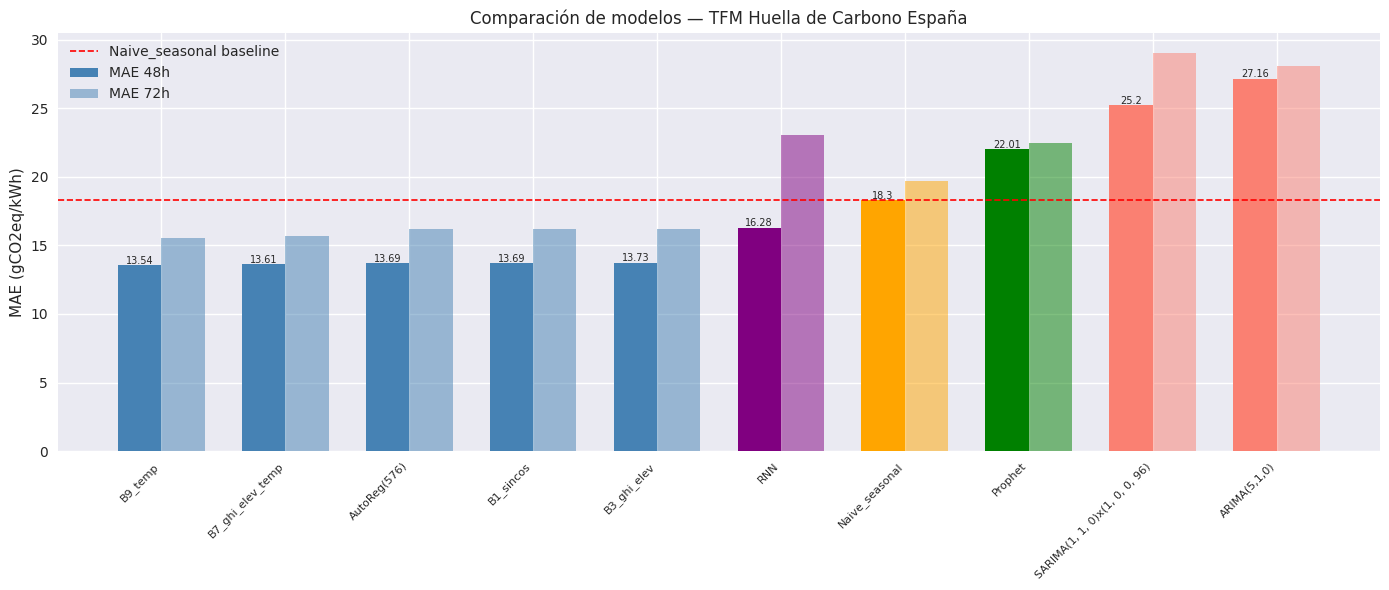

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

mae_48 = tabla_slides[("MAE", "48h")].values
mae_72 = tabla_slides[("MAE", "72h")].values
modelos = tabla_slides.index.tolist()

x     = np.arange(len(modelos))
width = 0.35

colors = []
for m in modelos:
    if m.startswith("B"):
        colors.append("steelblue")
    elif m in ["RNN"]:
        colors.append("purple")
    elif m == "Naive_seasonal":
        colors.append("orange")
    elif m == "Prophet":
        colors.append("green")
    else:
        colors.append("salmon")

ax.bar(x - width/2, mae_48, width, label="MAE 48h", color=colors)
ax.bar(x + width/2, mae_72, width, label="MAE 72h", color=colors, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("MAE (gCO2eq/kWh)")
ax.set_title("Comparación de modelos — TFM Huella de Carbono España")
ax.axhline(y=18.302, color="red", linestyle="--",
           linewidth=1.2, label="Naive_seasonal baseline")
ax.legend()

for i, v in enumerate(mae_48):
    ax.text(i - width/2, v + 0.1, str(round(v, 2)),
            ha="center", fontsize=7)

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/comparacion_slides.png", dpi=150, bbox_inches="tight")
plt.show()